<a href="https://colab.research.google.com/github/OlhaZahrebelna/Intelligent-Support-Ticket-Router-using-NLP/blob/main/03_BERT_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch --quiet

In [ ]:
# Standard library
import os
import random

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch

# Hugging Face
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


For fine-tuning, I selected `bert-base-uncased` because the dataset is relatively small and the main priority is classification quality rather than training speed. BERT is a strong pretrained transformer model that can capture contextual meaning in support ticket texts better than traditional baseline models.


In [ ]:
DATA_PATH = "/content/customer_support_tickets_cleaned.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run the preprocessing notebook first or upload the cleaned CSV file."
    )

df = pd.read_csv(DATA_PATH)

df.head()

,text,subject,body,queue,priority,type,language
0,"Account Disruption Dear Customer Support Team,...",Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,en
1,Query About Smart Home System Integration Feat...,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,en
2,Inquiry Regarding Invoice Details Dear Custome...,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,en
3,Question About Marketing Agency Software Compa...,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,en
4,"Feature Query Dear Customer Support,\n\nI hope...",Feature Query,"Dear Customer Support,\n\nI hope this message ...",Technical Support,high,Request,en


In [ ]:
df.shape

(28261, 7)

In [ ]:
df[["text", "queue"]].isna().sum()

,0
text,0
queue,0


In [ ]:
df["queue"].value_counts()

,count
queue,
Technical Support,8149
Product Support,5305
Customer Service,4269
IT Support,3333
Billing and Payments,2897
Returns and Exchanges,1402
Service Outages and Maintenance,1106
Sales and Pre-Sales,843
Human Resources,553


In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["queue"])

In [ ]:
pd.DataFrame({
    "Class": label_encoder.classes_,
    "Label": range(len(label_encoder.classes_))
})

,Class,Label
0,Billing and Payments,0
1,Customer Service,1
2,General Inquiry,2
3,Human Resources,3
4,IT Support,4
5,Product Support,5
6,Returns and Exchanges,6
7,Sales and Pre-Sales,7
8,Service Outages and Maintenance,8
9,Technical Support,9


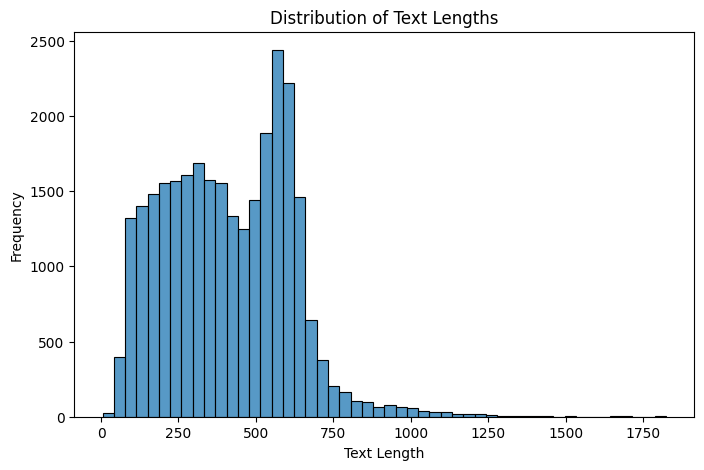

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['text'].apply(len), bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
X = df["text"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
token_lengths = df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x)) + 2
)

token_lengths.describe()

,text
count,28261.000000
mean,75.276529
std,38.990666
min,3.000000
25%,44.000000
50%,73.000000
75%,103.000000
max,419.000000


In [ ]:
(token_lengths > 128).mean() * 100

np.float64(5.902126605569513)

In [ ]:
max_length = 128

The maximum sequence length was set to 128 tokens because the token length analysis showed that most tickets are relatively short. The average text length is about 75 tokens, the median is 73 tokens, and 75% of the texts are shorter than 103 tokens. Only around 5.9% of tickets exceed 128 tokens. Therefore, `max_length = 128` preserves the majority of ticket information while reducing memory usage, training time, and computational cost during BERT fine-tuning.

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

In [ ]:
class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = TicketDataset(train_encodings, y_train)
val_dataset = TicketDataset(val_encodings, y_val)
test_dataset = TicketDataset(test_encodings, y_test)

In [ ]:
train_dataset[0].keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

This block creates a custom PyTorch dataset class for BERT training.  
The `TicketDataset` class combines tokenized text inputs with their corresponding labels and returns them in the format required by the Hugging Face `Trainer`.

Each dataset item contains:
- `input_ids` — token IDs of the text,
- `token_type_ids` — segment IDs used by BERT,
- `attention_mask` — mask that shows which tokens are real and which are padding,
- `labels` — encoded target class.

Then separate datasets are created for training, validation, and testing. This prepares the data for model fine-tuning and evaluation.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    }

In [ ]:
classes = np.arange(len(label_encoder.classes_))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.to_numpy()
)

class_weights = torch.tensor(weights, dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fn(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_ticket_router",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_dir="./logs",
    logging_steps=100,

    save_total_limit=2,
    report_to="none",

    seed=SEED,
    fp16=torch.cuda.is_available()
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

In [ ]:
model= AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


When loading bert-base-uncased for sequence classification, some pretrained heads related to masked language modeling and next sentence prediction are not used. At the same time, the new classification layer is randomly initialized because the pretrained checkpoint does not contain task-specific weights for the support ticket categories. This is expected and the classification head will be learned during fine-tuning.

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.805708,1.806306,0.280407,0.302178,0.322510,0.280108,0.374512,0.280407,0.267502
2,1.709329,1.627879,0.388766,0.461494,0.413445,0.415903,0.424635,0.388766,0.383307
3,1.209571,1.421385,0.486953,0.503094,0.541916,0.514357,0.502600,0.486953,0.484741
4,0.812001,1.408432,0.547988,0.642998,0.591589,0.604125,0.572582,0.547988,0.551808
5,0.535246,1.391684,0.636886,0.712383,0.651147,0.672911,0.643586,0.636886,0.636598
6,0.366037,1.498971,0.671827,0.687925,0.683249,0.684137,0.679389,0.671827,0.674531
7,0.249955,1.621495,0.693498,0.704036,0.709252,0.705193,0.695081,0.693498,0.693060
8,0.152704,1.962231,0.715170,0.757294,0.699840,0.724049,0.719804,0.715170,0.714891
9,0.114431,2.107908,0.725785,0.766318,0.712589,0.735936,0.728698,0.725785,0.725474
10,0.055391,2.142724,0.725343,0.760188,0.718012,0.736860,0.726511,0.725343,0.724896


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=25440, training_loss=0.7400688765933678, metrics={'train_runtime': 2424.9298, 'train_samples_per_second': 83.908, 'train_steps_per_second': 10.491, 'total_flos': 1.338476295055872e+16, 'train_loss': 0.7400688765933678, 'epoch': 10.0})

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.055391,2.142724,10,0.725343,0.760188,0.718012,0.736860,0.726511,0.725343,0.724896


{'eval_loss': 2.142723798751831,
 'eval_accuracy': 0.7253427686864219,
 'eval_macro_precision': 0.7601882628517198,
 'eval_macro_recall': 0.7180118799801456,
 'eval_macro_f1': 0.7368598465604462,
 'eval_weighted_precision': 0.7265105493046363,
 'eval_weighted_recall': 0.7253427686864219,
 'eval_weighted_f1': 0.7248959958579102}

In [ ]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_test.reset_index(drop=True),
    y_pred,
    target_names=label_encoder.classes_
))

print("Macro F1:", f1_score(
    y_test.reset_index(drop=True),
    y_pred,
    average="macro"
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.89      0.86      0.88       579
               Customer Service       0.70      0.70      0.70       854
                General Inquiry       0.81      0.69      0.75        81
                Human Resources       0.88      0.75      0.81       111
                     IT Support       0.69      0.67      0.68       667
                Product Support       0.71      0.70      0.70      1061
          Returns and Exchanges       0.77      0.71      0.74       280
            Sales and Pre-Sales       0.86      0.58      0.69       169
Service Outages and Maintenance       0.82      0.80      0.81       221
              Technical Support       0.70      0.77      0.74      1630

                       accuracy                           0.73      5653
                      macro avg       0.78      0.72      0.75      5653
                   weighted avg       0.74      0

The model generalized well on the test set. The validation Macro F1-score was 0.737, while the test Macro F1-score increased to 0.749, which shows that the model did not overfit to the validation data and maintained stable performance on unseen examples. The model performs especially well on clearly defined categories such as Billing and Payments, Human Resources, and Service Outages and Maintenance, while the remaining errors mostly occur between semantically similar support classes.

## Error Analysis

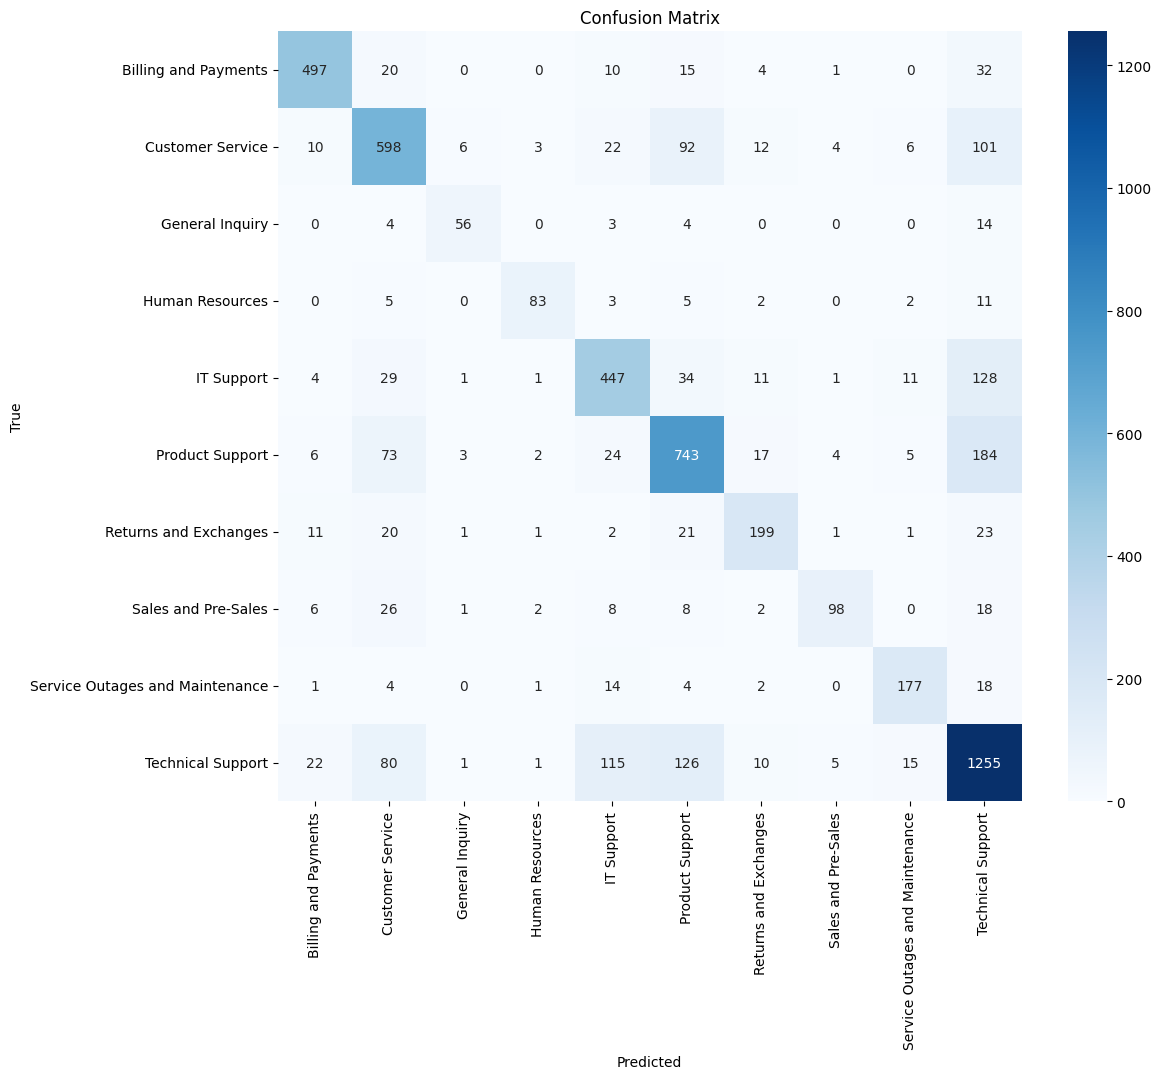

In [ ]:
cm = confusion_matrix(y_test.reset_index(drop=True), y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model predicts most classes correctly, with strong diagonal values across all categories. The largest number of errors occurs between semantically similar support queues. In particular, `Product Support`, `Technical Support`, `IT Support`, and `Customer Service` are often confused with each other because their ticket texts may contain overlapping vocabulary related to problems, products, services, and technical issues.

The most frequent misclassifications are:
- `Product Support` → `Technical Support` — 184 cases
- `IT Support` → `Technical Support` — 128 cases
- `Technical Support` → `Product Support` — 126 cases
- `Technical Support` → `IT Support` — 115 cases
- `Customer Service` → `Technical Support` — 101 cases
- `Customer Service` → `Product Support` — 92 cases

Overall, the model performs well, but the main source of error is the boundary between broad and closely related support categories. This suggests that these labels may need clearer definitions or more specific examples to help the model separate them better.

In [ ]:
y_true = y_test.reset_index(drop=True).to_numpy()
logits = predictions.predictions

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

pred_confidence = probs.max(axis=1)

true_class_probability = probs[np.arange(len(y_true)), y_true]

sorted_probs = np.sort(probs, axis=1)
confidence_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

result_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label_id": y_true,
    "predicted_label_id": y_pred,
    "true_label": label_encoder.inverse_transform(y_true),
    "predicted_label": label_encoder.inverse_transform(y_pred),
    "is_error": y_true != y_pred,
    "pred_confidence": pred_confidence,
    "true_class_probability": true_class_probability,
    "confidence_margin": confidence_margin
})

result_df.head()

,text,true_label_id,predicted_label_id,true_label,predicted_label,is_error,pred_confidence,true_class_probability,confidence_margin
0,Improve Digital Marketing Strategies with Enha...,9,9,Technical Support,Technical Support,False,0.999634,0.999634,0.999431
1,Security Protocols Following a Data Breach in ...,6,0,Returns and Exchanges,Billing and Payments,True,0.994545,0.000020,0.990116
2,Problem with Today's Uploads in PDFfiller We a...,9,9,Technical Support,Technical Support,False,0.999722,0.999722,0.999624
3,Strategies for Brand Growth in the Digital Spa...,1,5,Customer Service,Product Support,True,0.666986,0.160918,0.499003
4,Trouble with ClickUp Integration Smart-Thermom...,9,9,Technical Support,Technical Support,False,0.999815,0.999815,0.999751


In [ ]:
total = len(result_df)
errors_count = result_df["is_error"].sum()
correct_count = total - errors_count

print("Total examples:", total)
print("Correct predictions:", correct_count)
print("Errors:", errors_count)
print("Error rate:", errors_count / total)

Total examples: 5653
Correct predictions: 4153
Errors: 1500
Error rate: 0.2653458340704051


In [ ]:
per_class_errors = (
    result_df
    .groupby("true_label")
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

per_class_errors["error_rate"] = per_class_errors["errors"] / per_class_errors["total"]

per_class_errors = per_class_errors.sort_values("error_rate", ascending=False)

per_class_errors

,true_label,total,errors,avg_confidence,error_rate
7,Sales and Pre-Sales,169,71,0.939612,0.420118
4,IT Support,667,220,0.950480,0.329835
2,General Inquiry,81,25,0.945363,0.308642
1,Customer Service,854,256,0.940587,0.299766
5,Product Support,1061,318,0.953773,0.299717
6,Returns and Exchanges,280,81,0.956024,0.289286
3,Human Resources,111,28,0.959922,0.252252
9,Technical Support,1630,375,0.951748,0.230061
8,Service Outages and Maintenance,221,44,0.969901,0.199095
0,Billing and Payments,579,82,0.969066,0.141623


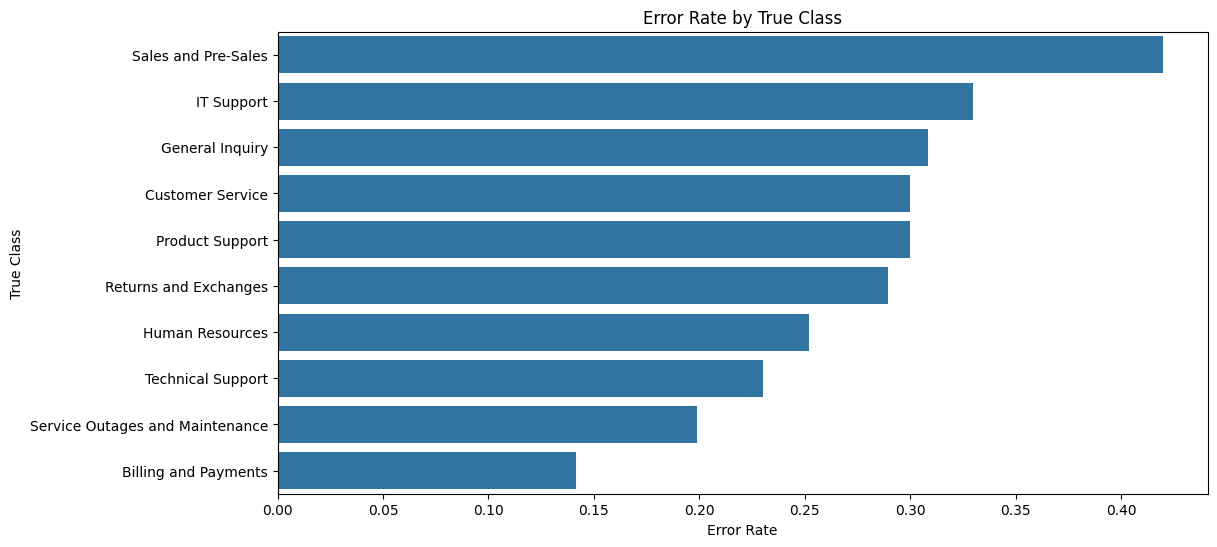

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=per_class_errors,
    x="error_rate",
    y="true_label"
)

plt.xlabel("Error Rate")
plt.ylabel("True Class")
plt.title("Error Rate by True Class")
plt.show()

Per-class error analysis shows that the highest error rate is observed for `Sales and Pre-Sales` at 42.0%. This class has relatively few examples, which makes it harder for the model to learn stable patterns. High error rates are also visible for `IT Support`, `General Inquiry`, `Customer Service`, and `Product Support`, where the error rate is around 30–33%. These categories are semantically close to other support classes, so their descriptions often overlap.

The lowest error rates are observed for `Billing and Payments` at 14.2% and `Service Outages and Maintenance` at 19.9%. This suggests that these categories contain more distinctive vocabulary and are easier for the model to separate.

An important observation is that the average confidence is high for all classes, even for categories with many errors. This means the model is often confident not only in correct predictions, but also in some wrong predictions. Therefore, future improvement should focus on better separating overlapping classes, reviewing ambiguous labels, and possibly applying confidence-based error analysis or calibration.

In [ ]:
errors_df = result_df[result_df["is_error"]].copy()

confusion_pairs = (
    errors_df
    .groupby(["true_label", "predicted_label"])
    .agg(
        count=("text", "size"),
        avg_confidence=("pred_confidence", "mean"),
        avg_true_class_probability=("true_class_probability", "mean")
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

confusion_pairs.head(20)

,true_label,predicted_label,count,avg_confidence,avg_true_class_probability
42,Product Support,Technical Support,184,0.926142,0.042556
33,IT Support,Technical Support,128,0.921716,0.038027
72,Technical Support,Product Support,126,0.889838,0.079348
71,Technical Support,IT Support,115,0.883426,0.110413
14,Customer Service,Technical Support,101,0.895902,0.031585
10,Customer Service,Product Support,92,0.905037,0.038236
68,Technical Support,Customer Service,80,0.888320,0.039164
35,Product Support,Customer Service,73,0.895235,0.046916
29,IT Support,Product Support,34,0.852791,0.014301
5,Billing and Payments,Technical Support,32,0.836515,0.059314


This analysis identifies the most frequent confusion pairs among incorrect predictions. The largest errors occur between closely related support categories, especially `Product Support`, `Technical Support`, `IT Support`, and `Customer Service`.

The most common mistake is `Product Support` being predicted as `Technical Support` with 184 cases. Other frequent errors include `IT Support` → `Technical Support`, `Technical Support` → `Product Support`, and `Technical Support` → `IT Support`. This confirms that the model struggles most with classes that describe similar technical or product-related issues.

An important point is that the model often makes these incorrect predictions with high confidence. For example, many wrong predictions have an average confidence above 0.88–0.92, while the probability assigned to the true class is very low. This means the model is not only confused, but also strongly confident in some incorrect decisions.

Overall, the main source of errors is semantic overlap between support categories. To improve the model, it would be useful to refine label definitions, review ambiguous training examples, and add more representative examples for classes that are frequently confused.

In [ ]:
def show_errors(true_class=None, predicted_class=None, n=10):
    subset = errors_df.copy()

    if true_class is not None:
        subset = subset[subset["true_label"] == true_class]

    if predicted_class is not None:
        subset = subset[subset["predicted_label"] == predicted_class]

    subset = subset.sort_values("pred_confidence", ascending=False)

    return subset[[
        "text",
        "true_label",
        "predicted_label",
        "pred_confidence",
        "true_class_probability",
        "confidence_margin"
    ]].head(n)

In [ ]:
show_errors(
    true_class="Customer Service",
    predicted_class="Product Support",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
1516,Automation Process Disruption Dear Customer Su...,Customer Service,Product Support,0.999891,0.000011,0.999849
4666,"Hello customer support, I am facing problems ...",Customer Service,Product Support,0.999887,0.000027,0.999850
3829,Concern Over Brand Engagement Noted a sudden d...,Customer Service,Product Support,0.999885,0.000023,0.999841
2600,A financial organization encountered data dis...,Customer Service,Product Support,0.999853,0.000085,0.999769
345,Problem with Brand Engagement We have noticed ...,Customer Service,Product Support,0.999848,0.000004,0.999777
4446,Query Regarding Inaccurate Campaign Metrics He...,Customer Service,Product Support,0.999843,0.000009,0.999768
4542,A financial organization encountered data dis...,Customer Service,Product Support,0.999816,0.000080,0.999737
5411,Issue with Financial Analytics Software Proces...,Customer Service,Product Support,0.999789,0.000015,0.999673
1153,Inconsistent Data Tracking in Digital Campaign...,Customer Service,Product Support,0.999727,0.000209,0.999518
2440,Enhancing Social Media Ad Performance Hello [N...,Customer Service,Product Support,0.999639,0.000298,0.999341


In [ ]:
show_errors(
    true_class="General Inquiry",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
2389,Problem with Hospital System Security breach f...,General Inquiry,IT Support,0.999800,0.000007,0.999714
3549,Concerns Regarding Scalable SaaS Project Manag...,General Inquiry,Technical Support,0.999697,0.000004,0.999509
1095,Social Media Campaign Performance Issues Follo...,General Inquiry,Customer Service,0.999584,0.000019,0.999287
4660,Notification of Data Security Incident A poten...,General Inquiry,Technical Support,0.999529,0.000005,0.999134
4733,Severe Underperformance of Digital Campaigns I...,General Inquiry,Product Support,0.998648,0.000011,0.997562
3430,Enhance Data Analytics Infrastructure Seek ass...,General Inquiry,IT Support,0.996278,0.000223,0.994519
4372,Security Protocols for Laptops Storing Sensiti...,General Inquiry,Product Support,0.995938,0.000093,0.992290
1262,Services for Data Analytics Is it possible to ...,General Inquiry,Customer Service,0.995322,0.001786,0.993536
5596,Incident Notification: Recent Data Breach Cust...,General Inquiry,Technical Support,0.995093,0.000096,0.991761
5392,Report of Data Security Breach A possible data...,General Inquiry,Technical Support,0.993810,0.000011,0.990647


In [ ]:
result_df["char_length"] = result_df["text"].astype(str).apply(len)
result_df["token_length"] = result_df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x))
)

length_analysis = (
    result_df
    .assign(length_group=pd.cut(
        result_df["token_length"],
        bins=[0, 64, 128, 256, 512, 10000],
        labels=["0-64", "65-128", "129-256", "257-512", "512+"]
    ))
    .groupby("length_group", observed=False)
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

length_analysis["error_rate"] = length_analysis["errors"] / length_analysis["total"]

length_analysis

,length_group,total,errors,avg_confidence,error_rate
0,0-64,2495,697,0.953217,0.279359
1,65-128,2852,670,0.954434,0.234923
2,129-256,298,131,0.930484,0.439597
3,257-512,8,2,0.996561,0.250000
4,512+,0,0,NaN,NaN


Length-based error analysis shows that the model performs best on medium-length texts. Tickets with 65–128 tokens have the lowest error rate at 23.5%, which confirms that the selected `max_length = 128` is appropriate for this dataset.

Short texts with 0–64 tokens have a slightly higher error rate of 27.9%, likely because they contain less context for the model to understand the correct support category. The highest error rate is observed for longer texts with 129–256 tokens at 44.0%. This may happen because longer tickets often contain multiple issues or more complex descriptions, making classification harder.

Very long texts are rare in the dataset, so the 257–512 group is too small to draw reliable conclusions. Overall, the model works most reliably on typical ticket lengths, while very short or longer, more complex messages remain more challenging.

## Conclusion

In this notebook, a BERT-based transformer model was fine-tuned for automatic support ticket classification. The main evaluation metric for model comparison was Macro F1-score, because the dataset is imbalanced and the goal is to evaluate model performance across all support queue categories, not only the majority classes.

The fine-tuned `bert-base-uncased` model achieved a test Macro F1-score of approximately 0.749. This is the best result among all tested models in the project. The previous best classical machine learning model, the balanced Linear SVM with optimized TF-IDF features, achieved a Macro F1-score of approximately 0.739. Therefore, based on Macro F1-score, BERT outperformed the strongest baseline model by about 0.01.

Although the improvement over Linear SVM is relatively small, it is still meaningful because Macro F1 gives equal importance to all classes. BERT showed particularly strong performance on several minority or more specific classes, including `General Inquiry`, `Sales and Pre-Sales`, `Returns and Exchanges`, and `Service Outages and Maintenance`. This indicates that the transformer model was able to capture contextual patterns that are useful for distinguishing less frequent support categories.

At the same time, the results show that the classification task remains challenging. The model still makes errors between semantically similar categories such as `Technical Support`, `Product Support`, `IT Support`, and `Customer Service`. These classes often share similar vocabulary and overlapping ticket descriptions, which makes them difficult to separate even for a contextual language model.

Overall, the BERT fine-tuning experiment produced the best Macro F1-score in the project and should be considered the strongest model according to the selected evaluation criterion. However, because the improvement over the Linear SVM baseline is modest, the final model choice should also consider computational cost, training time, inference speed, and deployment complexity. If the priority is maximum Macro F1-score, BERT is the best model. If simplicity and efficiency are more important, the balanced Linear SVM remains a strong alternative.
